# L4. Finding the Right Memory

Memory is also what you saw, so photos join the notes: same shard, a second named vector. Find a photo by describing it, then narrow recall with a filter on category and price.

## 1. One shard, two named vectors

Notes and photos share one memory store, each kind in its own vector space: text 768 numbers wide, images 512.

In [1]:
from helper import (before_after, embed_query_clip, fresh_start,
                    load_memories, results_table,
                    show_photo_results, store_notes, store_photos,
                    text_search)
from qdrant_edge import (Distance, EdgeConfig, EdgeShard,
                         EdgeVectorParams)

SHARD_DIR = fresh_start("./mem_shard")

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
shard = EdgeShard.create(SHARD_DIR, config)
print("Shard ready: text 768-d (Nomic), image 512-d (CLIP)")

Shard ready: text 768-d (Nomic), image 512-d (CLIP)


## 2. Store the day's text notes

Lesson 3 taught this write in full; `store_notes` repeats it, embedding each note and storing it as a point.

In [2]:
notes = load_memories(
    "./ro_shared_data/memories.json",
    source_type="text",
)
store_notes(shard, notes)

Category,Memory
food,Great little coffee place on 5th with outdoor seating and fast wifi
work,Standup with Sarah moved to Thursday to review the Q3 roadmap
errands,"Pick up dry cleaning before Friday, ticket is on the fridge"
work,Idea: batch the weekly report so it drafts itself every Monday


## 3. Store a photo library

A bank of everyday photos joins the same shard, embedded with CLIP into the `image` vector.


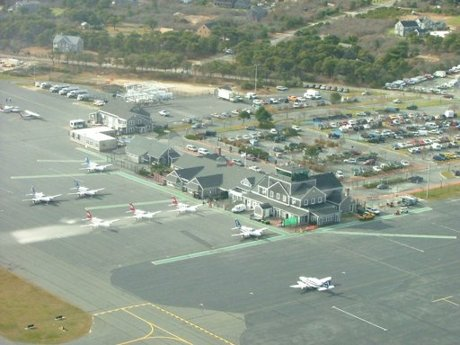
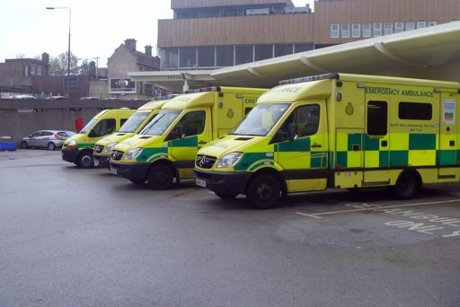
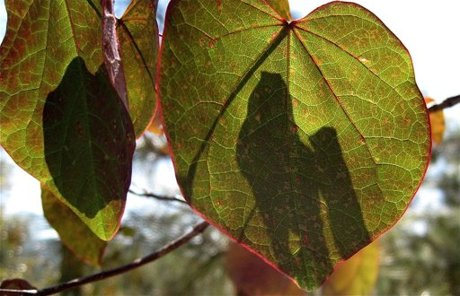
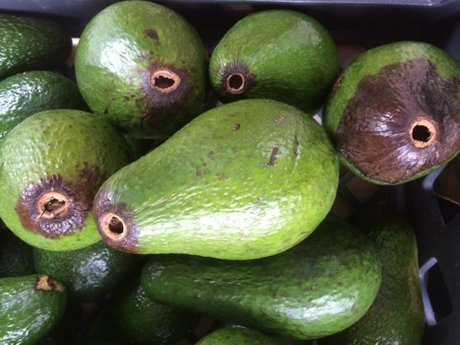
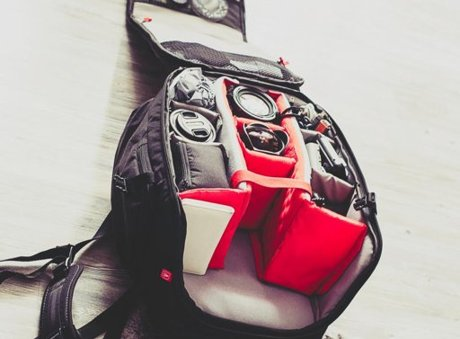
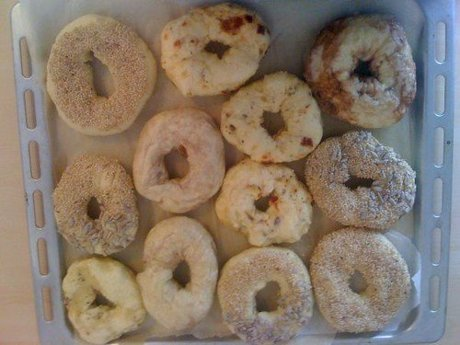

In [3]:
store_photos(shard, "./ro_shared_data/bank")

## 4. Find a photo by describing it

Describe what you remember seeing. The description is embedded into CLIP's shared space and matched against the photo vectors, so words find pictures. The search always returns its closest photo, so the answer is the nearest thing in the bank, not a guarantee.


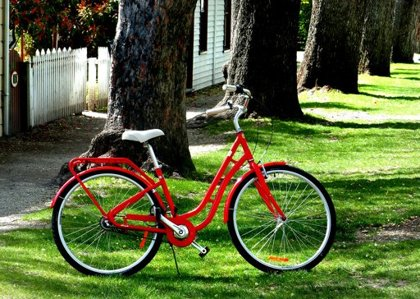

In [4]:
from qdrant_edge import Query, QueryRequest

# Type any description and re-run. Try: "a slice of pizza",
# "a cute puppy dog", "a sunflower", "a sailboat on water".
my_description = "a red bicycle"

description_vector = embed_query_clip(my_description)

photo_hits = shard.query(
    QueryRequest(
        query=Query.Nearest(description_vector, using="image"),
        limit=1,
        with_payload=True,
    )
)
show_photo_results(photo_hits, "./ro_shared_data/bank",
                  my_description)

## 5. Recall with a filter

Index two payload fields, then ask the same question twice: similarity alone, and narrowed to food under $15.

In [5]:
from qdrant_edge import PayloadSchemaType, UpdateOperation

shard.update(UpdateOperation.create_field_index(
    "category", PayloadSchemaType.Keyword))
shard.update(UpdateOperation.create_field_index(
    "price", PayloadSchemaType.Float))
shard.optimize()
print("Indexed category and price")

Indexed category and price


In [6]:
query = "somewhere to eat"
results_table(text_search(shard, query), "Similarity only",
              caption=f'Q: {query}')

Score,Category,Price,Memory
0.553,food,-,Great little coffee place on 5th with outdoor seating and fast wifi
0.536,work,-,Found a quiet cafe with good wifi to work from near the park
0.520,food,-,"Try the new ramen place downtown, everyone raves about the tonkotsu"
0.495,food,$3,Coffee run to the espresso bar near the office


In [7]:
from qdrant_edge import (FieldCondition, Filter, MatchValue,
                         RangeFloat)

cheap_food = Filter(
    must=[
        FieldCondition(key="category", match=MatchValue(value="food")),
        FieldCondition(key="price", range=RangeFloat(lt=15)),
    ]
)
before_after(
    query,
    text_search(shard, query),
    text_search(shard, query, cheap_food),
    "Narrowed to food under $15",
    kept="passed the filter",
    dropped="dropped by the filter",
)

,Score,Category,Price,Memory
❌ dropped by the filter,0.553,food,-,Great little coffee place on 5th with outdoor seating and fast wifi
❌ dropped by the filter,0.536,work,-,Found a quiet cafe with good wifi to work from near the park
❌ dropped by the filter,0.520,food,-,"Try the new ramen place downtown, everyone raves about the tonkotsu"
✅ passed the filter,0.495,food,$3,Coffee run to the espresso bar near the office
✅ passed the filter,0.476,food,$4,New bakery on the corner does an amazing morning cronut
